In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [6]:
def euler(f, x0, y0, h, x_end):
    xs = [x0]
    ys = [y0]
    while xs[-1] < x_end:
        xs.append(xs[-1] + h)
        ys.append(ys[-1] + f(xs[-1], ys[-1]))
    return np.array(xs), np.array(ys)

# Q.11

In [3]:
def f(x, y):
    return 2*np.cos(x)*y

In [8]:
# h = 0.1
x_euler, y_euler = euler(f, 0, 1, 0.25, 1)
print(x_euler)
print(y_euler)

[0.   0.25 0.5  0.75 1.  ]
[ 1.          2.93782484  8.09419255 19.93905373 41.48528714]


In [14]:
sol = solve_ivp(f, [0, 1], [1], method='RK45', max_step=0.25)
x_rk45 = sol["t"]
y_rk45 = sol["y"][0]
print(x_rk45)
print(y_rk45)

[0.         0.07582013 0.32582013 0.57582013 0.82582013 1.        ]
[1.         1.16357251 1.89681015 2.97144625 4.35015629 5.38138451]


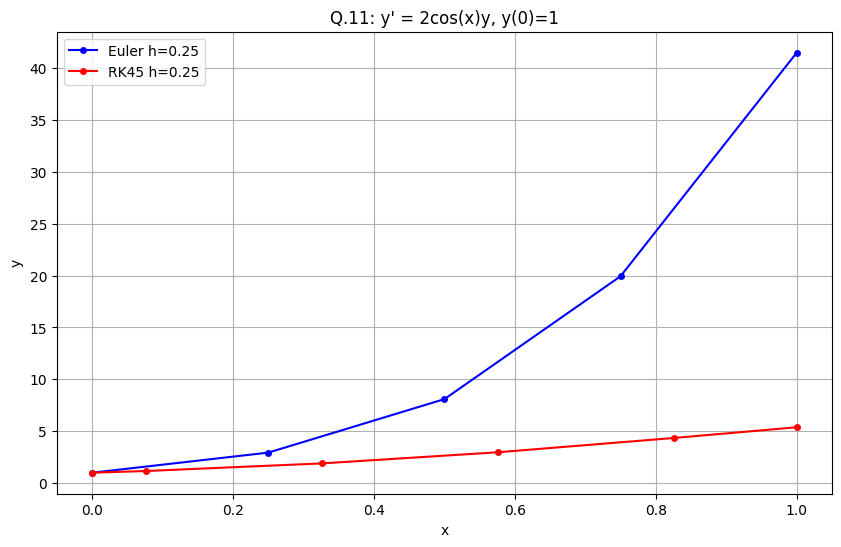

In [16]:
plt.figure(figsize=(10, 6))

# Plot Euler
plt.plot(x_euler, y_euler, 'b-o', label='Euler h=0.25', markersize=4)

# Plot RK45
plt.plot(x_rk45, y_rk45, 'r-o', label='RK45 h=0.25', markersize=4)

plt.xlabel('x')
plt.ylabel('y')
plt.title("Q.11: y' = 2cos(x)y, y(0)=1")
plt.legend()
plt.grid(True)
plt.show()

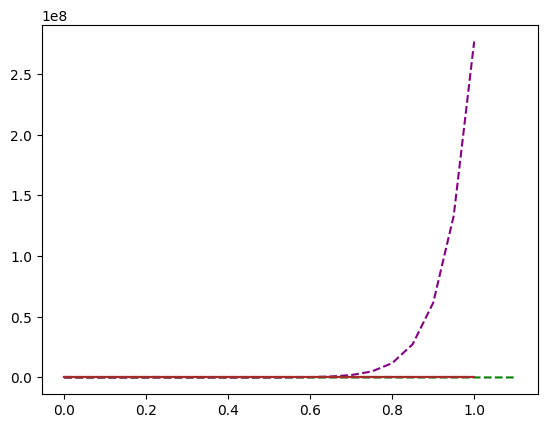

In [17]:
for h, color_e, color_r in [(0.25, 'blue', 'red'), 
                              (0.1, 'green', 'orange'), 
                              (0.05, 'purple', 'brown')]:
    xe, ye = euler(f, 0, 1, h, 1)
    sol = solve_ivp(f, [0, 1], [1], method='RK45', max_step=h)
    
    plt.plot(xe, ye, '--', color=color_e, label=f'Euler h={h}')
    plt.plot(sol["t"], sol["y"][0], '-', color=color_r, label=f'RK45 h={h}')

# Q. 12

In [18]:
def f(x, y):
    return y*(10-2*y)

In [ ]:
# h = 0.1
x_euler, y_euler = euler(f, 0, 1, 0.25, 1)
print(x_euler)
print(y_euler)

In [19]:
sol = solve_ivp(f, [0, 1], [1], method='RK45', max_step=0.25)
x_rk45 = sol["t"]
y_rk45 = sol["y"][0]
print(x_rk45)
print(y_rk45)

[0.         0.04614542 0.20143057 0.39336955 0.53035505 0.66734055
 0.85695302 1.        ]
[1.         1.4198642  3.2609852  4.63720849 4.90264794 4.97471575
 4.99558066 4.99892306]


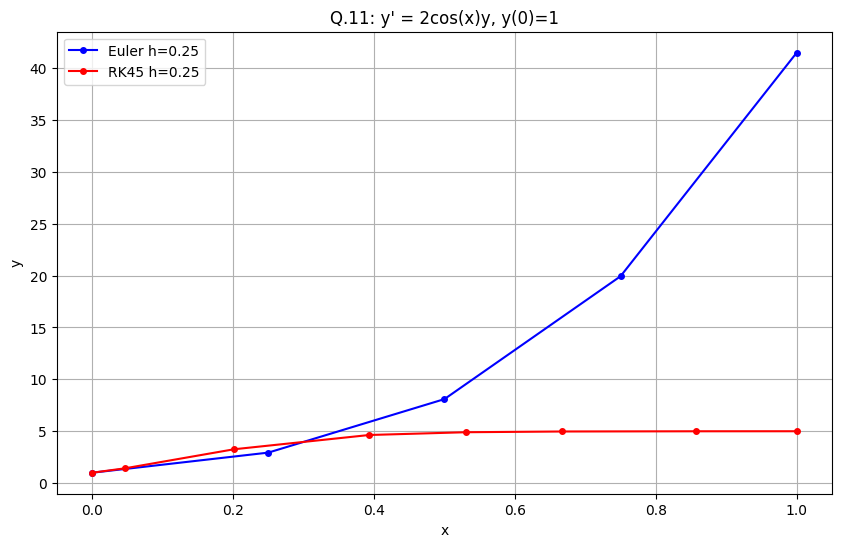

In [20]:
plt.figure(figsize=(10, 6))

# Plot Euler
plt.plot(x_euler, y_euler, 'b-o', label='Euler h=0.25', markersize=4)

# Plot RK45
plt.plot(x_rk45, y_rk45, 'r-o', label='RK45 h=0.25', markersize=4)

plt.xlabel('x')
plt.ylabel('y')
plt.title("Q.11: y' = 2cos(x)y, y(0)=1")
plt.legend()
plt.grid(True)
plt.show()

# Q.13

In [ ]:
def f(x, y):
    return 2*x*(y**2)

## Using Euler

In [24]:
# h = 0.1
x_euler, y_euler = euler(f, 0, 1, 0.1, 1)
print(y_euler[-1])

-268972789849276248608820794372234353547432812240970273531508957276886532466683911966817184187671714390443768978742298289283538053861464290421006489486126094257846872838638271044383295676265625128888905169605329034791364696947393563615248672540950066500299168108777740557019949837005960570553490115890525237309007025757099066384222224923909180963975588201826262896504255393204627670249254839113512709762460328353348290272015023583934583868507409979884280751546562586333634193379126713980665896598106013498103769790643910884402416570870930325989641508892224439884628998887485167652729939017502563180934453039755774244835578086337238542266132999287779692810872122696746544561517224610552257238347511062826603316257739868761972541957907637400203389346579783387232716594786248931675369660567718498023082929177829229701047694776708398699459188554140417930943020138040463917112192337251718397766911199694144589345869135833208572620797592617306894284351720598691323788173655694783259956250589851258748458066

In [25]:
# h = 0.05
x_euler, y_euler = euler(f, 0, 1, 0.05, 1)
print(y_euler[-1])

ValueError: Exceeds the limit (4300 digits) for integer string conversion; use sys.set_int_max_str_digits() to increase the limit

## Using RK45

In [27]:
# h = 0.1
sol = solve_ivp(f, [0, 1], [1], method='RK45', max_step=0.1)
sol["y"][0][-1]

np.float64(4.9990884579421975)

In [28]:
# h = 0.05
sol = solve_ivp(f, [0, 1], [1], method='RK45', max_step=0.05)
sol["y"][0][-1]

np.float64(4.999092086243437)

The approximations differ so greatly because y(x) = 1/(1-x²) has a singularity at x = 1. Euler's method, being a low-order method, accumulates error rapidly near the blowup and produces wildly inaccurate results. RK45 is more stable but still only approximates a value near the singularity. Neither can truly capture y(1) = infinity.